#**CHURN PREDICTION**

##IMPORTING LIBRARIES

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import recall_score, accuracy_score, classification_report, confusion_matrix, precision_recall_curve,f1_score,precision_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from time import time
import warnings
warnings.filterwarnings('ignore')

##DATA LOADING

In [5]:
df1= pd.read_csv("/Users/rajkaranyp/Documents/churn-prediction/data/churn-bigml-80.csv")
df1.head(5)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [6]:
df2= pd.read_csv("/Users/rajkaranyp/Documents/churn-prediction/data/churn-bigml-20.csv")
df2.head(5)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [7]:
print(df1.shape)
print(df2.shape)

(2666, 20)
(667, 20)


In [8]:
df=pd.concat([df1,df2],axis=0)
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [9]:
df.shape

(3333, 20)

##DATA EXPLORATION & CLEANING

In [10]:
df.shape

(3333, 20)

In [11]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3333 entries, 0 to 666
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   float6

In [13]:
df['State'].value_counts()

State
WV    106
MN     84
NY     83
AL     80
OR     78
WI     78
OH     78
WY     77
VA     77
CT     74
MI     73
ID     73
VT     73
UT     72
TX     72
IN     71
KS     70
MD     70
MT     68
NJ     68
NC     68
CO     66
NV     66
WA     66
MA     65
RI     65
MS     65
AZ     64
MO     63
FL     63
ND     62
NM     62
ME     62
NE     61
DE     61
OK     61
SD     60
SC     60
KY     59
IL     58
NH     56
AR     55
GA     54
DC     54
TN     53
HI     53
AK     52
LA     51
PA     45
IA     44
CA     34
Name: count, dtype: int64

In [14]:
df['International plan'].value_counts()

International plan
No     3010
Yes     323
Name: count, dtype: int64

In [15]:
df['Voice mail plan'].value_counts()

Voice mail plan
No     2411
Yes     922
Name: count, dtype: int64

In [16]:
pd.DataFrame({
    'Count': df['Churn'].value_counts(),
    'Percentage': df['Churn'].value_counts()/np.sum(df['Churn'].value_counts()/100)
})


,Count,Percentage
Churn,,
False,2850,85.508551
True,483,14.491449


In [17]:
df.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [18]:
categorical_columns=['State','International plan','Voice mail plan']

numerical_columns=df.drop(columns=categorical_columns,axis=1)
numerical_columns.head()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


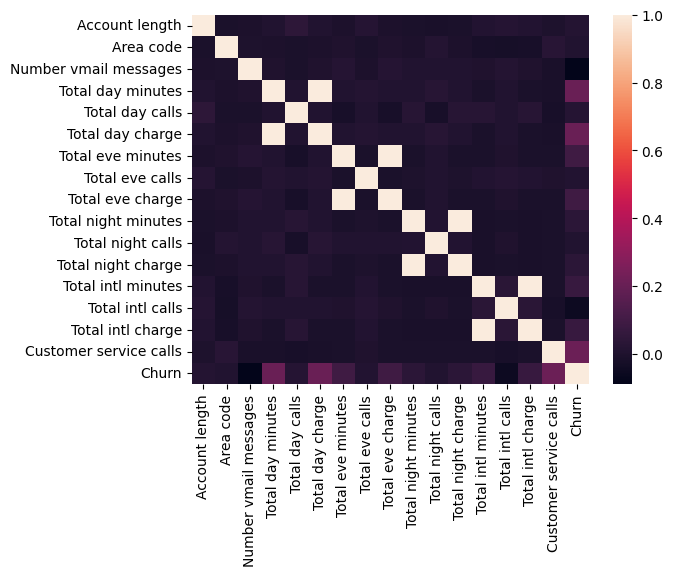

In [19]:
sns.heatmap(numerical_columns.corr())
plt.show()

In [20]:
# Make a copy to avoid modifying the original df
df_vif = df.copy()

# Convert binary categorical features to numerical
df_vif['International plan'] = df_vif['International plan'].map({'Yes': 1, 'No': 0})
df_vif['Voice mail plan'] = df_vif['Voice mail plan'].map({'Yes': 1, 'No': 0})

# One-hot encode 'Area code' (since it's categorical despite being int64)
df_vif = pd.get_dummies(df_vif, columns=['Area code'], drop_first=True)

# Drop the target variable 'Churn' and high cardinality 'State'
X = df_vif.drop(columns=['Churn', 'State'])

# Ensure all columns in X are numeric before VIF calculation
X_numeric = X.select_dtypes(include=[np.number])

# Drop any columns that might have constant values (zero variance) as VIF cannot be computed for them
X_numeric = X_numeric.loc[:, (X_numeric != X_numeric.iloc[0]).any()]

# Check if X_numeric is empty after dropping constant columns
if X_numeric.empty:
    print("No suitable numeric features found for VIF calculation after transformations and constant value check.")
else:
    # Add a constant to the DataFrame (required for VIF calculation)
    X_const = add_constant(X_numeric)

    # Calculate VIF for each feature
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_const.columns
    vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

    # Sort by VIF in descending order for better readability
    vif_data = vif_data.sort_values(by="VIF", ascending=False)

    print("Variance Inflation Factor (VIF) for features:")
    print(vif_data)


Variance Inflation Factor (VIF) for features:
                   feature           VIF
7         Total day charge  1.047617e+07
5        Total day minutes  1.047616e+07
10        Total eve charge  2.237335e+06
8        Total eve minutes  2.237334e+06
11     Total night minutes  6.387661e+05
13      Total night charge  6.387648e+05
14      Total intl minutes  6.907441e+04
16       Total intl charge  6.907440e+04
0                    const  1.429712e+02
3          Voice mail plan  1.190453e+01
4    Number vmail messages  1.190351e+01
2       International plan  1.008221e+00
6          Total day calls  1.004704e+00
1           Account length  1.004366e+00
15        Total intl calls  1.003815e+00
12       Total night calls  1.003217e+00
17  Customer service calls  1.002660e+00
9          Total eve calls  1.002310e+00


In [21]:
drop_columns=['State','Total eve charge','Total day charge','Total night charge','Total intl charge']

In [22]:
df.drop(columns=drop_columns,inplace=True)
df.head()

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn
0,128,415,No,Yes,25,265.1,110,197.4,99,244.7,91,10.0,3,1,False
1,107,415,No,Yes,26,161.6,123,195.5,103,254.4,103,13.7,3,1,False
2,137,415,No,No,0,243.4,114,121.2,110,162.6,104,12.2,5,0,False
3,84,408,Yes,No,0,299.4,71,61.9,88,196.9,89,6.6,7,2,False
4,75,415,Yes,No,0,166.7,113,148.3,122,186.9,121,10.1,3,3,False


In [23]:
categorical_columns=['International plan','Voice mail plan']

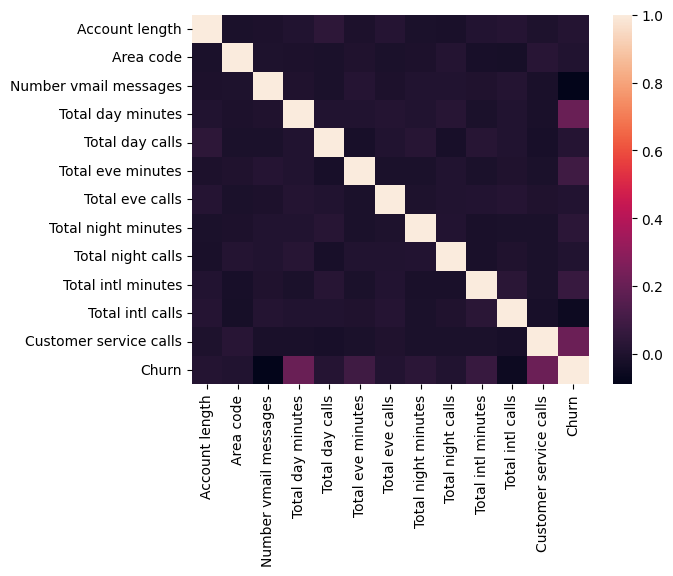

In [24]:
sns.heatmap(df.drop(columns=categorical_columns).corr())
plt.show()

##DATA ENCODING

In [25]:
df.head()

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn
0,128,415,No,Yes,25,265.1,110,197.4,99,244.7,91,10.0,3,1,False
1,107,415,No,Yes,26,161.6,123,195.5,103,254.4,103,13.7,3,1,False
2,137,415,No,No,0,243.4,114,121.2,110,162.6,104,12.2,5,0,False
3,84,408,Yes,No,0,299.4,71,61.9,88,196.9,89,6.6,7,2,False
4,75,415,Yes,No,0,166.7,113,148.3,122,186.9,121,10.1,3,3,False


In [26]:
df['International plan']=df['International plan'].map({'Yes':1,'No':0})
df['Voice mail plan']=df['Voice mail plan'].map({'Yes':1,'No':0})
df['Churn']=df['Churn'].map({True:1,False:0})
df.head()

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn
0,128,415,0,1,25,265.1,110,197.4,99,244.7,91,10.0,3,1,0
1,107,415,0,1,26,161.6,123,195.5,103,254.4,103,13.7,3,1,0
2,137,415,0,0,0,243.4,114,121.2,110,162.6,104,12.2,5,0,0
3,84,408,1,0,0,299.4,71,61.9,88,196.9,89,6.6,7,2,0
4,75,415,1,0,0,166.7,113,148.3,122,186.9,121,10.1,3,3,0


##DATA SPLITTING

In [27]:
X=df.drop(columns='Churn')
Y=df['Churn']

In [28]:
X_Train,X_Test,Y_Train,Y_Test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [29]:
print(X_Train.shape)
print(X_Test.shape)
print(Y_Train.shape)
print(Y_Test.shape)

(2666, 14)
(667, 14)
(2666,)
(667,)


In [30]:
Y_Train.value_counts()

Churn
0    2280
1     386
Name: count, dtype: int64

In [31]:
Y_Test.value_counts()

Churn
0    570
1     97
Name: count, dtype: int64

##MODEL BUILDING

##RANDOM FOREST - BASELINE


In [32]:
rf=RandomForestClassifier(n_estimators=300,random_state=42,criterion='gini',max_features='sqrt',oob_score=True)
rf.fit(X_Train,Y_Train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [33]:
rf_train_pred=rf.predict(X_Train)
rf_test_pred=rf.predict(X_Test)


In [34]:
rf_recall=recall_score(Y_Test,rf_test_pred)
rf_recall

0.6185567010309279

In [35]:
rf_pr_auc=precision_recall_curve(Y_Test,rf_test_pred)
rf_pr_auc

(array([0.14542729, 0.96774194, 1.        ]),
 array([1.       , 0.6185567, 0.       ]),
 array([0, 1]))

In [36]:
rf_classication_report=classification_report(Y_Test,rf_test_pred)
print(rf_classication_report)

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       570
           1       0.97      0.62      0.75        97

    accuracy                           0.94       667
   macro avg       0.95      0.81      0.86       667
weighted avg       0.94      0.94      0.94       667



In [37]:
rf.feature_importances_

array([0.05009908, 0.01398855, 0.08475879, 0.0194061 , 0.02797985,
       0.2582648 , 0.05223463, 0.0952511 , 0.04521175, 0.06200111,
       0.04825509, 0.0777075 , 0.06299401, 0.10184764])

In [38]:
rf.oob_score_

0.9493623405851462

##XGBOOST- BASELINE

In [39]:
scale_value_train=len(Y_Train[Y_Train==0])/len(Y_Train[Y_Train==1])
scale_value_train

5.9067357512953365

In [40]:
scale_value_test=len(Y_Test[Y_Test==0])/len(Y_Test[Y_Test==1])
scale_value_test

5.876288659793815

In [41]:
XGB=xgb.XGBClassifier(random_state=42,scale_pos_weight=5.8)
XGB.fit(X_Train,Y_Train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [42]:
XGB_train_pred=XGB.predict(X_Train)
XGB_test_pred=XGB.predict(X_Test)

In [43]:
XGB_recall=recall_score(Y_Test,XGB_test_pred)
XGB_recall

0.7628865979381443

In [44]:
XGB_pr_auc=precision_recall_curve(Y_Test,XGB_test_pred)
XGB_pr_auc

(array([0.14542729, 0.925     , 1.        ]),
 array([1.       , 0.7628866, 0.       ]),
 array([0, 1]))

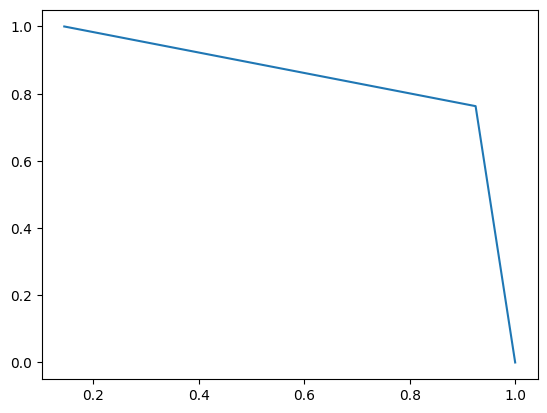

In [45]:
plt.plot(XGB_pr_auc[0],XGB_pr_auc[1])
plt.show()

In [46]:
XGB_classification_report=classification_report(Y_Test,XGB_test_pred)
print(XGB_classification_report)

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       570
           1       0.93      0.76      0.84        97

    accuracy                           0.96       667
   macro avg       0.94      0.88      0.91       667
weighted avg       0.96      0.96      0.95       667



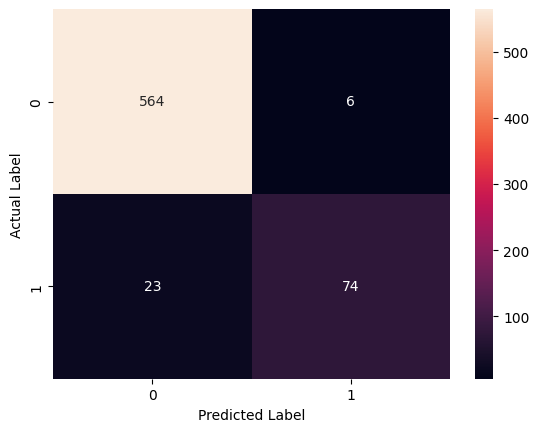

In [47]:
sns.heatmap(confusion_matrix(Y_Test,XGB_test_pred),annot=True,fmt='d')
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

##XGBOOST - HYPERPARAMETER TUNING

In [48]:
param_grid=({
        'n_estimators':[100,200,300,400],
        'max_depth':[4,5,6,7],
        'learning_rate': [0.001,0.01,0.1,1],
        'subsample':[0.5,0.7,1],
        'colsample_bytree':[0.5,0.7,1],
        'gamma':[0,0.1,0.2,0.3],
        'reg_lambda':[0,0.1,0.2],
        'reg_alpha':[0,0.1,0.2],
        'min_child_weight':[1,2,3,4,5],
        'scale_pos_weight': [3, 5, 6]
   })

In [49]:
Xgb_model=xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

In [50]:
random_search=RandomizedSearchCV(
    estimator=Xgb_model,
    param_distributions=param_grid,
    n_iter=200,
    scoring='recall',
    cv=5,
    verbose=2,
    n_jobs=-1
    )

In [51]:
random_search.fit(X_Train,Y_Train)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[CV] END colsample_bytree=1, gamma=0.2, learning_rate=1, max_depth=5, min_child_weight=4, n_estimators=300, reg_alpha=0.1, reg_lambda=0.2, scale_pos_weight=6, subsample=1; total time=   0.1s
[CV] END colsample_bytree=1, gamma=0.2, learning_rate=1, max_depth=5, min_child_weight=4, n_estimators=300, reg_alpha=0.1, reg_lambda=0.2, scale_pos_weight=6, subsample=1; total time=   0.1s
[CV] END colsample_bytree=1, gamma=0.2, learning_rate=1, max_depth=5, min_child_weight=4, n_estimators=300, reg_alpha=0.1, reg_lambda=0.2, scale_pos_weight=6, subsample=1; total time=   0.1s
[CV] END colsample_bytree=1, gamma=0.2, learning_rate=1, max_depth=5, min_child_weight=4, n_estimators=300, reg_alpha=0.1, reg_lambda=0.2, scale_pos_weight=6, subsample=1; total time=   0.1s
[CV] END colsample_bytree=1, gamma=0.2, learning_rate=1, max_depth=5, min_child_weight=4, n_estimators=300, reg_alpha=0.1, reg_lambda=0.2, scale_pos_weight=6, subsample=1; 

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.5, 0.7, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.001, 0.01, ...], 'max_depth': [4, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",200
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.

In [52]:
random_search.best_params_

{'subsample': 1,
 'scale_pos_weight': 6,
 'reg_lambda': 0,
 'reg_alpha': 0,
 'n_estimators': 100,
 'min_child_weight': 4,
 'max_depth': 5,
 'learning_rate': 0.01,
 'gamma': 0.3,
 'colsample_bytree': 0.7}

In [53]:
random_search.best_score_

np.float64(0.8265734265734265)

In [54]:
best_parameters=random_search.best_params_
print(best_parameters)

{'subsample': 1, 'scale_pos_weight': 6, 'reg_lambda': 0, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 4, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.7}


In [55]:
best_parameters.update({
    "random_state":42,
    "use_label_encoder":False,
    "eval_metric":'logloss'
})

In [56]:
best_parameters

{'subsample': 1,
 'scale_pos_weight': 6,
 'reg_lambda': 0,
 'reg_alpha': 0,
 'n_estimators': 100,
 'min_child_weight': 4,
 'max_depth': 5,
 'learning_rate': 0.01,
 'gamma': 0.3,
 'colsample_bytree': 0.7,
 'random_state': 42,
 'use_label_encoder': False,
 'eval_metric': 'logloss'}

In [57]:
start_time=time()
print("Training Started at:",start_time)
final_XGB=xgb.XGBClassifier(**best_parameters)
final_XGB.fit(X_Train,Y_Train)
train_time=time()-start_time
print("Training completed at:",train_time)

Training Started at: 1774464048.9645178
Training completed at: 0.10497403144836426


In [58]:
final_XGB_train_pred=final_XGB.predict(X_Train)
final_XGB_test_pred=final_XGB.predict(X_Test)

In [59]:
final_XGB_recall=recall_score(Y_Test,final_XGB_test_pred)
final_XGB_recall

0.8350515463917526

In [60]:
final_XGB_accuracy=accuracy_score(Y_Test,final_XGB_test_pred)
final_XGB_accuracy

0.9430284857571214

(array([0.14542729, 0.78640777, 1.        ]), array([1.        , 0.83505155, 0.        ]), array([0, 1]))


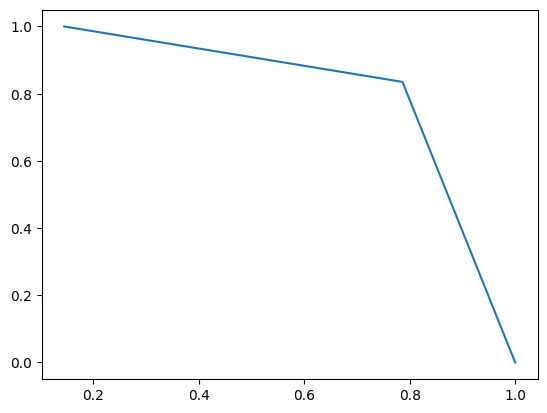

In [61]:
final_XGB_pr_auc=precision_recall_curve(Y_Test,final_XGB_test_pred)
print(final_XGB_pr_auc)
plt.plot(final_XGB_pr_auc[0],final_XGB_pr_auc[1])
plt.show()

In [62]:
final_XGB_f1_score=f1_score(Y_Test,final_XGB_test_pred)
final_XGB_f1_score

0.81

In [63]:
final_XGB_classification_report=classification_report(Y_Test,final_XGB_test_pred)
print(final_XGB_classification_report)

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       570
           1       0.79      0.84      0.81        97

    accuracy                           0.94       667
   macro avg       0.88      0.90      0.89       667
weighted avg       0.94      0.94      0.94       667



In [64]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Get predicted probabilities (NOT labels)
y_probs = final_XGB.predict_proba(X_Test)[:, 1]

# Define thresholds
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)

    precision = precision_score(Y_Test, y_pred)
    recall = recall_score(Y_Test, y_pred)
    f1 = f1_score(Y_Test, y_pred)

    tn, fp, fn, tp = confusion_matrix(Y_Test, y_pred).ravel()

    results.append({
        'threshold': t,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'false_positives': fp,
        'false_negatives': fn
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

print(results_df)

    threshold  precision    recall  f1_score  false_positives  false_negatives
0        0.10   0.145427  1.000000  0.253927              570                0
1        0.15   0.145427  1.000000  0.253927              570                0
2        0.20   0.145646  1.000000  0.254260              569                0
3        0.25   0.146970  1.000000  0.256275              563                0
4        0.30   0.172662  0.989691  0.294028              460                1
5        0.35   0.256831  0.969072  0.406048              272                3
6        0.40   0.427184  0.907216  0.580858              118                9
7        0.45   0.648438  0.855670  0.737778               45               14
8        0.50   0.786408  0.835052  0.810000               22               16
9        0.55   0.833333  0.824742  0.829016               16               17
10       0.60   0.867470  0.742268  0.800000               11               25
11       0.65   0.949153  0.577320  0.717949        

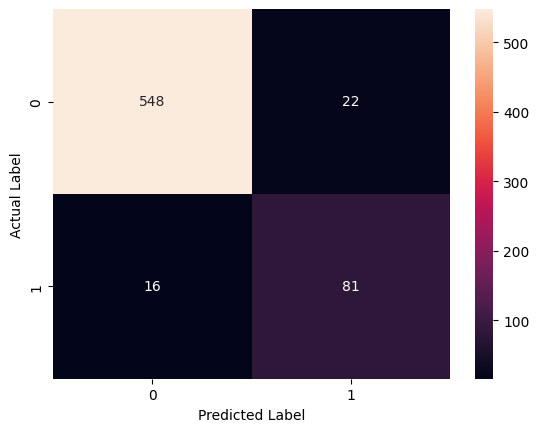

In [65]:
sns.heatmap(confusion_matrix(Y_Test,final_XGB_test_pred),annot=True,fmt='d')
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()